In [ ]:
# ============================================================
# EARTRACK - VERSION COMPLETA FINAL CORREGIDA
# GOOGLE COLAB + 39 IMAGENES + JSON ANNOTATIONS
# ============================================================

# ============================================================
# 1. MONTAR GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2. IMPORTAR LIBRERIAS
# ============================================================

import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt

# ============================================================
# 3. DEFINIR RUTAS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/Entrega final/sampledataset"

IMAGES_FOLDER = os.path.join(BASE_PATH, "img")

ANN_FOLDER = os.path.join(BASE_PATH, "ann")

print("===================================")
print("RUTAS")
print("===================================")

print("Imagenes:")
print(IMAGES_FOLDER)

print("\nAnnotations:")
print(ANN_FOLDER)

# ============================================================
# 4. VERIFICAR CARPETAS
# ============================================================

if not os.path.exists(IMAGES_FOLDER):

    raise Exception(
        f"No existe carpeta:\n{IMAGES_FOLDER}"
    )

if not os.path.exists(ANN_FOLDER):

    raise Exception(
        f"No existe carpeta:\n{ANN_FOLDER}"
    )

# ============================================================
# 5. LEER JSON ANNOTATIONS
# ============================================================

parameters = {}

ann_files = [
    f for f in os.listdir(ANN_FOLDER)
    if f.endswith(".json")
]

print("\n===================================")
print("JSON ENCONTRADOS")
print("===================================")

for file in ann_files:

    print(file)

    full_path = os.path.join(
        ANN_FOLDER,
        file
    )

    try:

        with open(full_path, "r") as f:

            data = json.load(f)

            parameters[file] = data

    except Exception as e:

        print(f"Error leyendo {file}")
        print(e)

print("\nTotal JSON cargados:")
print(len(parameters))

# ============================================================
# 6. LEER IMAGENES PNG
# ============================================================

images = {
    "top": {},
    "side": {}
}

image_files = [
    f for f in os.listdir(IMAGES_FOLDER)
    if f.endswith(".png")
]

print("\n===================================")
print("IMAGENES ENCONTRADAS")
print("===================================")

for f in image_files:
    print(f)

# ============================================================
# 7. CLASIFICAR IMAGENES
# ============================================================

for file in image_files:

    full_path = os.path.join(
        IMAGES_FOLDER,
        file
    )

    img = cv2.imread(full_path)

    if img is None:

        print(f"\nError leyendo: {file}")
        continue

    # --------------------------------------------------------
    # TOP VIEW
    # --------------------------------------------------------

    if "_tv0_" in file:

        images["top"][file] = img

        print(f"\nTOP cargada: {file}")

    # --------------------------------------------------------
    # SIDE VIEW
    # --------------------------------------------------------

    elif "_sv" in file:

        try:

            angle_part = file.split("_sv")[1]

            angle = angle_part.split("_")[0]

            angle = int(angle)

        except:

            angle = -1

        images["side"][file] = {
            "image": img,
            "angle": angle
        }

        print(f"\nSIDE cargada: {file} | angulo={angle}")

# ============================================================
# 8. ASOCIAR JSON CON IMAGENES
# ============================================================

annotations = {}

for json_name in parameters.keys():

    image_name = json_name.replace(".json", "")

    annotations[image_name] = parameters[json_name]

print("\n===================================")
print("ANNOTATIONS ASOCIADAS")
print("===================================")

print(f"Total annotations: {len(annotations)}")

# ============================================================
# 9. RESUMEN GENERAL
# ============================================================

print("\n===================================")
print("RESUMEN")
print("===================================")

print(f"Imagenes side: {len(images['side'])}")
print(f"Imagenes top: {len(images['top'])}")
print(f"Annotations JSON: {len(parameters)}")

# ============================================================
# 10. MOSTRAR IMAGENES
# ============================================================

total_images = len(images["side"])

cols = 4

rows = int(np.ceil(total_images / cols))

plt.figure(figsize=(18, rows * 4))

i = 1

for file in images["side"]:

    img = images["side"][file]["image"]

    angle = images["side"][file]["angle"]

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(rows, cols, i)

    plt.imshow(img_rgb)

    plt.title(f"{file}\nSV {angle}")

    plt.axis("off")

    i += 1

plt.tight_layout()

plt.show()

# ============================================================
# 11. FUNCION DE SEGMENTACION
# ============================================================

def segment_plant(img):

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2HSV
    )

    # --------------------------------------------------------
    # VERDES
    # --------------------------------------------------------

    lower_green = np.array([20,30,30])
    upper_green = np.array([100,255,255])

    mask_green = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    # --------------------------------------------------------
    # MARRONES / TALLO
    # --------------------------------------------------------

    lower_brown = np.array([5,20,20])
    upper_brown = np.array([30,255,255])

    mask_brown = cv2.inRange(
        hsv,
        lower_brown,
        upper_brown
    )

    # --------------------------------------------------------
    # COMBINAR
    # --------------------------------------------------------

    mask = cv2.bitwise_or(
        mask_green,
        mask_brown
    )

    # --------------------------------------------------------
    # LIMPIEZA
    # --------------------------------------------------------

    kernel = np.ones((5,5), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    return mask

# ============================================================
# 12. SEGMENTAR IMAGENES
# ============================================================

segmented_images = {}

for file in images["side"]:

    img = images["side"][file]["image"]

    mask = segment_plant(img)

    segmented_images[file] = mask

# ============================================================
# 13. MOSTRAR SEGMENTACION
# ============================================================

total_images = len(segmented_images)

cols = 4

rows = int(np.ceil(total_images / cols))

plt.figure(figsize=(18, rows * 4))

i = 1

for file in segmented_images:

    angle = images["side"][file]["angle"]

    plt.subplot(rows, cols, i)

    plt.imshow(
        segmented_images[file],
        cmap="gray"
    )

    plt.title(f"SEG SV {angle}")

    plt.axis("off")

    i += 1

plt.tight_layout()

plt.show()

# ============================================================
# 14. ESQUELETIZACION
# ============================================================

skeletons = {}

for file in segmented_images:

    binary = segmented_images[file] > 0

    skeleton = skeletonize(binary)

    skeletons[file] = skeleton

# ============================================================
# 15. MOSTRAR ESQUELETOS
# ============================================================

total_images = len(skeletons)

cols = 4

rows = int(np.ceil(total_images / cols))

plt.figure(figsize=(18, rows * 4))

i = 1

for file in skeletons:

    angle = images["side"][file]["angle"]

    plt.subplot(rows, cols, i)

    plt.imshow(
        skeletons[file],
        cmap="gray"
    )

    plt.title(f"SKEL SV {angle}")

    plt.axis("off")

    i += 1

plt.tight_layout()

plt.show()

# ============================================================
# 16. DISTANCE TRANSFORM
# ============================================================

distance_maps = {}

for file in segmented_images:

    binary = segmented_images[file] > 0

    dist = distance_transform_edt(binary)

    distance_maps[file] = dist

# ============================================================
# 17. MOSTRAR DISTANCE MAPS
# ============================================================

total_images = len(distance_maps)

cols = 4

rows = int(np.ceil(total_images / cols))

plt.figure(figsize=(18, rows * 4))

i = 1

for file in distance_maps:

    angle = images["side"][file]["angle"]

    plt.subplot(rows, cols, i)

    plt.imshow(distance_maps[file])

    plt.title(f"DIST SV {angle}")

    plt.axis("off")

    i += 1

plt.tight_layout()

plt.show()

# ============================================================
# 18. DETECCION SIMPLE DE TALLO
# ============================================================

def detect_stem(mask):

    h, w = mask.shape

    stem_x = []
    stem_y = []

    for y in range(h):

        xs = np.where(mask[y,:] > 0)[0]

        if len(xs) > 0:

            x_center = int(np.mean(xs))

            stem_x.append(x_center)
            stem_y.append(y)

    return stem_x, stem_y

# ============================================================
# 19. MEDIR ANCHO DEL TALLO
# ============================================================

stem_measurements = {}

for file in segmented_images:

    mask = segmented_images[file]

    dist = distance_maps[file]

    stem_x, stem_y = detect_stem(mask)

    widths = []
    ys = []

    for x, y in zip(stem_x, stem_y):

        if y < dist.shape[0] and x < dist.shape[1]:

            width = dist[y, x] * 2

            widths.append(width)
            ys.append(y)

    stem_measurements[file] = {
        "y": ys,
        "width": widths
    }

# ============================================================
# 20. DETECCION SIMPLE DE MAZORCA
# ============================================================

ear_positions = {}

for file in stem_measurements:

    widths = np.array(
        stem_measurements[file]["width"]
    )

    ys = np.array(
        stem_measurements[file]["y"]
    )

    if len(widths) > 0:

        idx = np.argmax(widths)

        ear_y = ys[idx]

        ear_width = widths[idx]

        ear_positions[file] = {
            "y": ear_y,
            "width": ear_width
        }

# ============================================================
# 21. MOSTRAR MAZORCA DETECTADA
# ============================================================

for file in images["side"]:

    img = images["side"][file]["image"].copy()

    angle = images["side"][file]["angle"]

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(5,8))

    plt.imshow(img_rgb)

    if file in ear_positions:

        y = ear_positions[file]["y"]

        plt.axhline(
            y=y,
            linewidth=3
        )

    plt.title(f"Mazorca detectada SV {angle}")

    plt.axis("off")

    plt.show()

# ============================================================
# 22. AREA DE PLANTA
# ============================================================

plant_areas = {}

for file in segmented_images:

    mask = segmented_images[file]

    area = np.sum(mask > 0)

    plant_areas[file] = area

# ============================================================
# 23. COMPARAR CON JSON ANNOTATIONS
# ============================================================

print("\n===================================")
print("COMPARACION PNG vs JSON")
print("===================================")

matches = 0

for file in images["side"]:

    if file in annotations:

        matches += 1

        print(f"\nMATCH:")
        print(file)

print(f"\nTotal matches: {matches}")

# ============================================================
# 24. RESULTADOS FINALES
# ============================================================

print("\n===================================")
print("RESULTADOS")
print("===================================")

for file in plant_areas:

    angle = images["side"][file]["angle"]

    print(f"\nArchivo: {file}")

    print(f"Angulo: {angle}")

    print(
        f"Area planta: "
        f"{plant_areas[file]} pixeles"
    )

    if file in ear_positions:

        print(
            f"Posicion mazorca Y: "
            f"{ear_positions[file]['y']}"
        )

        print(
            f"Ancho estimado: "
            f"{ear_positions[file]['width']:.2f}"
        )

# ============================================================
# 25. GUARDAR RESULTADOS
# ============================================================

results_path = os.path.join(
    BASE_PATH,
    "resultados_eartrack.txt"
)

with open(results_path, "w") as f:

    f.write("RESULTADOS EARTRACK\n\n")

    f.write(f"Imagenes: {IMAGES_FOLDER}\n")
    f.write(f"Annotations: {ANN_FOLDER}\n\n")

    for file in plant_areas:

        angle = images["side"][file]["angle"]

        f.write(f"Archivo: {file}\n")

        f.write(f"Angulo: {angle}\n")

        f.write(
            f"Area planta: "
            f"{plant_areas[file]}\n"
        )

        if file in ear_positions:

            f.write(
                f"Posicion mazorca Y: "
                f"{ear_positions[file]['y']}\n"
            )

            f.write(
                f"Ancho estimado: "
                f"{ear_positions[file]['width']:.2f}\n"
            )

        f.write("\n")

print("\n===================================")
print("RESULTADOS GUARDADOS")
print("===================================")

print(results_path)

IMAGENES ANGULO 60
plant-1_task-6635_sv60_cabin-2.png
plant-1_task-6815_sv60_cabin-1.png
plant-1_task-6841_sv60_cabin-1.png

ORDEN TEMPORAL
plant-1_task-6635_sv60_cabin-2.png
plant-1_task-6815_sv60_cabin-1.png
plant-1_task-6841_sv60_cabin-1.png

PRIMER DIA
plant-1_task-6635_sv60_cabin-2.png

ULTIMO DIA
plant-1_task-6841_sv60_cabin-1.png

CRECIMIENTO AREA
Area inicial: 63516
Area final: 509839
Crecimiento pixeles: 446323
Crecimiento porcentaje: 702.69%

CRECIMIENTO VERTICAL
Altura inicial: 753
Altura final: 2184
Crecimiento vertical: 1431
Crecimiento vertical porcentaje: 190.04%

HOJAS
Hojas estimadas: 0

FORMA APROXIMADA
Area aproximada: 578328


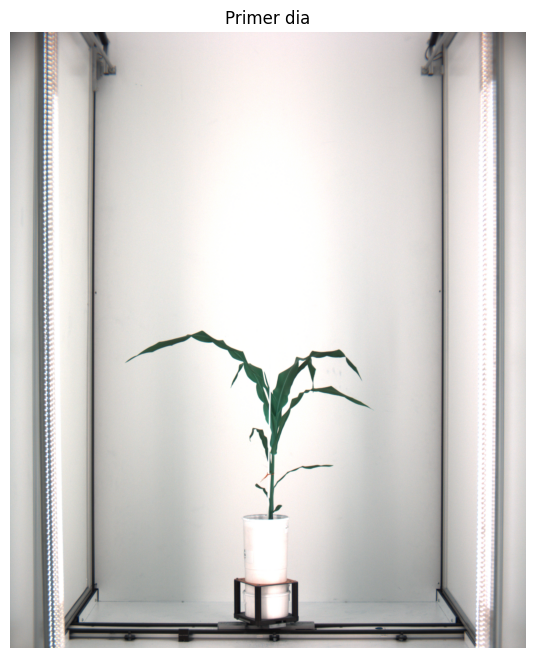

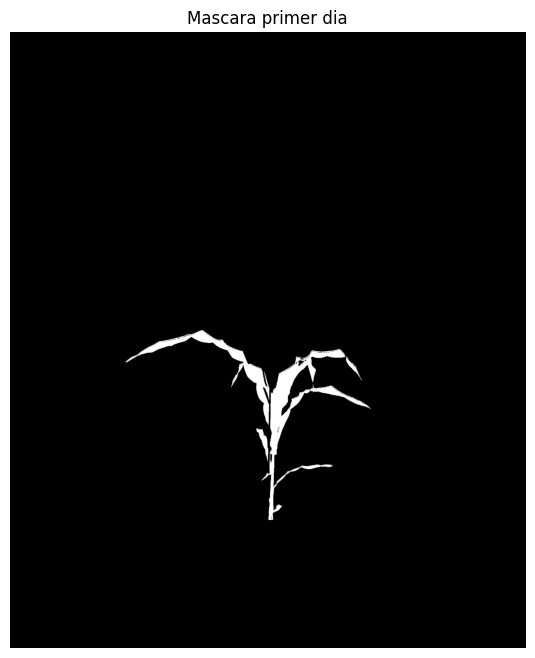

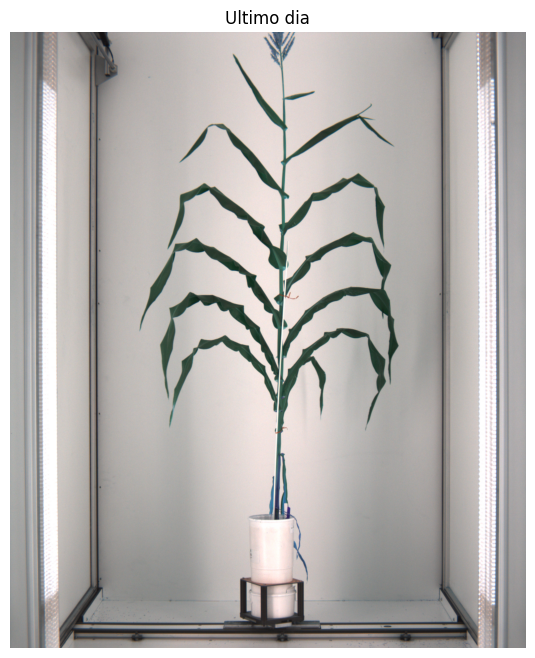

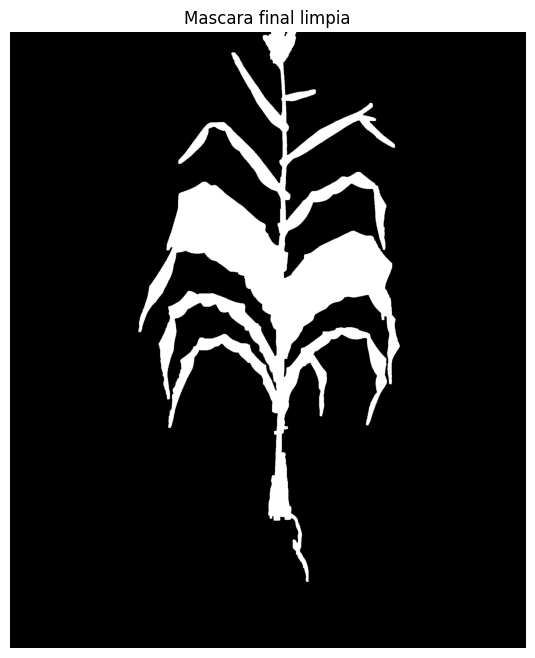

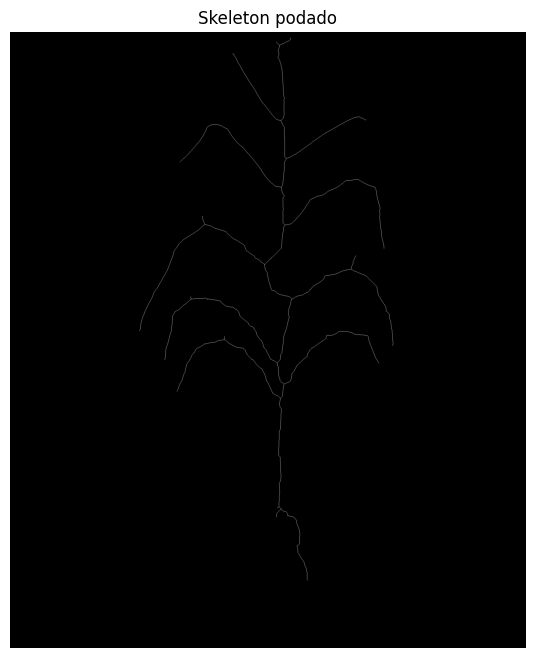

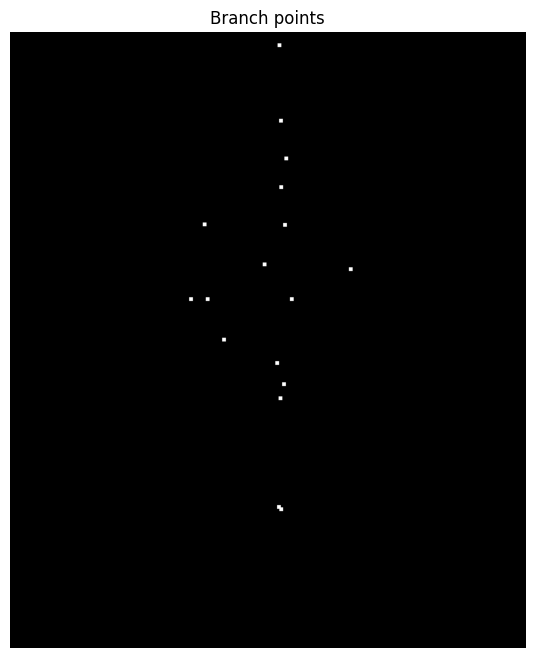

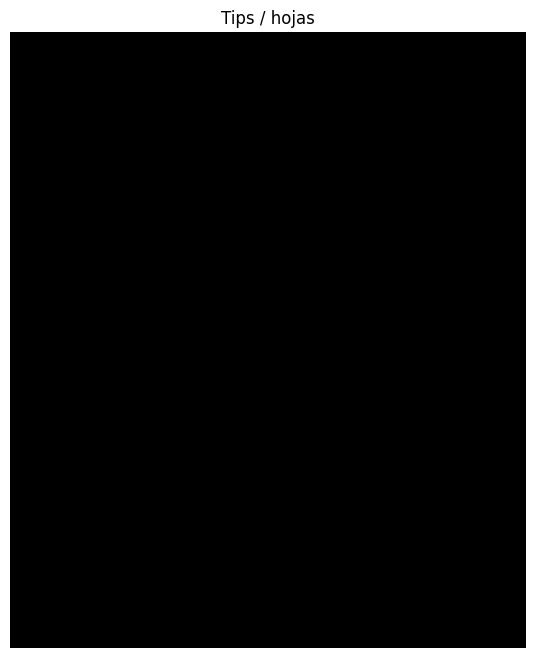

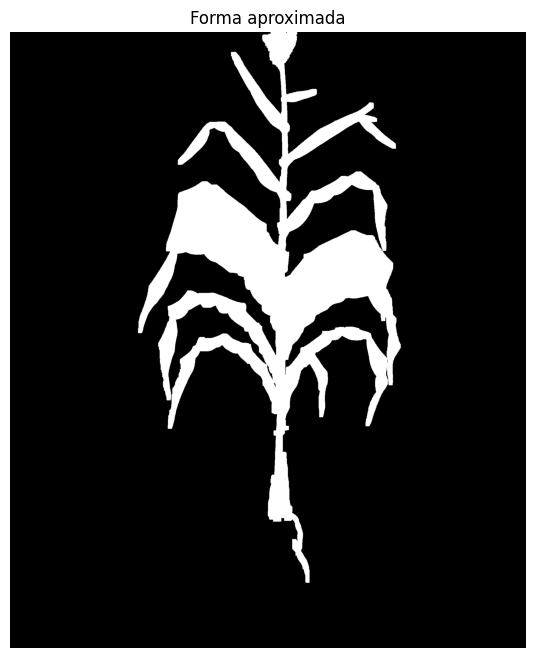


RESULTADOS FINALES
Imagen inicial: plant-1_task-6635_sv60_cabin-2.png
Imagen final: plant-1_task-6841_sv60_cabin-1.png
Area inicial: 63516
Area final: 509839
Crecimiento pixeles: 446323
Crecimiento porcentaje: 702.69%
Altura inicial: 753
Altura final: 2184
Crecimiento vertical: 1431
Crecimiento vertical porcentaje: 190.04%
Hojas estimadas: 0
Area aproximada: 578328

ARCHIVO GUARDADO
/content/drive/MyDrive/Entrega final/sampledataset/resultados_plantcv_parte2.txt


In [ ]:
# ============================================================
# PARTE 2 - ANALISIS DE CRECIMIENTO CON PLANTCV
# SOLO USANDO TEMAS DE CLASE / SESION 10
# SIN USAR CV2
# ============================================================

# ============================================================
# 1. INSTALAR PLANTCV
# ============================================================

!pip install plantcv

# ============================================================
# 2. IMPORTAR LIBRERIAS
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from plantcv import plantcv as pcv

# ============================================================
# 3. DEFINIR RUTAS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/Entrega final/sampledataset"

IMAGES_FOLDER = os.path.join(BASE_PATH, "img")

# ============================================================
# 4. LISTAR IMAGENES ANGULO 60
# ============================================================

all_images = [
    f for f in os.listdir(IMAGES_FOLDER)
    if "_sv60_" in f and f.endswith(".png")
]

print("===================================")
print("IMAGENES ANGULO 60")
print("===================================")

for f in all_images:
    print(f)

# ============================================================
# 5. ORDENAR IMAGENES
# ============================================================

def extract_task_number(filename):

    task_part = filename.split("task-")[1]

    number = task_part.split("_")[0]

    return int(number)

all_images = sorted(
    all_images,
    key=extract_task_number
)

print("\n===================================")
print("ORDEN TEMPORAL")
print("===================================")

for f in all_images:
    print(f)

# ============================================================
# 6. PRIMER Y ULTIMO DIA
# ============================================================

first_image_name = all_images[0]

last_image_name = all_images[-1]

print("\n===================================")
print("PRIMER DIA")
print(first_image_name)

print("\nULTIMO DIA")
print(last_image_name)

# ============================================================
# 7. CARGAR IMAGENES
# ============================================================

first_path = os.path.join(
    IMAGES_FOLDER,
    first_image_name
)

last_path = os.path.join(
    IMAGES_FOLDER,
    last_image_name
)

first_img, first_path, first_filename = pcv.readimage(
    filename=first_path
)

last_img, last_path, last_filename = pcv.readimage(
    filename=last_path
)

# ============================================================
# 8. SEGMENTACION
# ============================================================

# ------------------------------------------------------------
# PRIMER DIA
# ------------------------------------------------------------

first_gray = pcv.rgb2gray_hsv(
    rgb_img=first_img,
    channel='s'
)

first_mask = pcv.threshold.binary(
    gray_img=first_gray,
    threshold=40,
    object_type='light'
)

# ROI primer dia

roi2 = pcv.roi.rectangle(
    img=first_mask,
    x=450,
    y=700,
    h=1300,
    w=1200
)

kept_mask2 = pcv.roi.filter(
    mask=first_mask,
    roi=roi2,
    roi_type='partial'
)

# ------------------------------------------------------------
# ULTIMO DIA
# ------------------------------------------------------------

last_gray = pcv.rgb2gray_hsv(
    rgb_img=last_img,
    channel='s'
)

last_mask = pcv.threshold.binary(
    gray_img=last_gray,
    threshold=40,
    object_type='light'
)

# ============================================================
# 9. LIMPIEZA DE MASCARAS
# ============================================================

first_mask = pcv.fill(
    bin_img=kept_mask2,
    size=1000
)

last_mask = pcv.fill(
    bin_img=last_mask,
    size=1000
)

# ============================================================
# 10. ROI ULTIMO DIA
# ============================================================

roi1 = pcv.roi.rectangle(
    img=last_img,
    x=450,
    y=0,
    h=2000,
    w=1200
)

# ============================================================
# 11. FILTRAR ROI
# ============================================================

kept_mask = pcv.roi.filter(
    mask=last_mask,
    roi=roi1,
    roi_type='partial'
)

# ============================================================
# 12. LIMPIEZA FINAL
# ============================================================

# eliminar objetos pequeños

kept_mask = pcv.fill(
    bin_img=kept_mask,
    size=1000
)

# unir tallo

kept_mask = pcv.dilate(
    gray_img=kept_mask,
    ksize=7,
    i=2
)

# suavizar bordes

kept_mask = pcv.erode(
    gray_img=kept_mask,
    ksize=5,
    i=1
)

# llenar huecos

kept_mask = pcv.fill_holes(
    bin_img=kept_mask
)

# ============================================================
# 13. AREA
# ============================================================

first_area = np.sum(first_mask > 0)

last_area = np.sum(kept_mask > 0)

# ============================================================
# 14. CRECIMIENTO AREA
# ============================================================

growth_pixels = last_area - first_area

growth_percent = (
    (growth_pixels / first_area) * 100
)

print("\n===================================")
print("CRECIMIENTO AREA")
print("===================================")

print(f"Area inicial: {first_area}")

print(f"Area final: {last_area}")

print(f"Crecimiento pixeles: {growth_pixels}")

print(f"Crecimiento porcentaje: {growth_percent:.2f}%")

# ============================================================
# 15. CRECIMIENTO VERTICAL
# ============================================================

first_rows = np.where(first_mask > 0)[0]

first_height = np.max(first_rows) - np.min(first_rows)

last_rows = np.where(kept_mask > 0)[0]

last_height = np.max(last_rows) - np.min(last_rows)

vertical_growth = last_height - first_height

vertical_growth_percent = (
    (vertical_growth / first_height) * 100
)

print("\n===================================")
print("CRECIMIENTO VERTICAL")
print("===================================")

print(f"Altura inicial: {first_height}")

print(f"Altura final: {last_height}")

print(f"Crecimiento vertical: {vertical_growth}")

print(f"Crecimiento vertical porcentaje: {vertical_growth_percent:.2f}%")

# ============================================================
# 16. FORMA APROXIMADA
# ============================================================

hull = pcv.dilate(
    gray_img=kept_mask,
    ksize=4,
    i=2
)

# ============================================================
# 17. ESQUELETO
# ============================================================

skeleton = pcv.morphology.skeletonize(
    mask=kept_mask
)

# ============================================================
# 18. PODAR ESQUELETO
# ============================================================

pruned_skel, seg_img, edge_objects = pcv.morphology.prune(
    skel_img=skeleton,
    size=500,
    mask=kept_mask
)

# ============================================================
# 19. PUNTOS DE RAMIFICACION
# ============================================================

branch_pts_img = pcv.morphology.find_branch_pts(
    skel_img=pruned_skel,
    mask=kept_mask
)

# visualizar mejor

branch_pts_vis = pcv.dilate(
    gray_img=branch_pts_img,
    ksize=15,
    i=1
)

# ============================================================
# 20. PUNTOS EXTREMOS
# ============================================================

tip_pts_img = pcv.morphology.find_tips(
    skel_img=pruned_skel
)

# eliminar ruido pequeño

tip_pts_img = pcv.fill(
    bin_img=tip_pts_img,
    size=30
)

# visualizar mejor

tip_pts_vis = pcv.dilate(
    gray_img=tip_pts_img,
    ksize=15,
    i=1
)

# ============================================================
# 21. CONTAR HOJAS
# ============================================================

leaf_count = len(
    np.unique(
        tip_pts_img[tip_pts_img > 0]
    )
)

print("\n===================================")
print("HOJAS")
print("===================================")

print(f"Hojas estimadas: {leaf_count}")

# ============================================================
# 22. AREA APROXIMADA
# ============================================================

convex_area = np.sum(hull > 0)

print("\n===================================")
print("FORMA APROXIMADA")
print("===================================")

print(f"Area aproximada: {convex_area}")

# ============================================================
# 23. MOSTRAR RESULTADOS
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(first_img)

plt.title("Primer dia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(first_mask, cmap='gray')

plt.title("Mascara primer dia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(last_img)

plt.title("Ultimo dia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(kept_mask, cmap='gray')

plt.title("Mascara final limpia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(pruned_skel, cmap='gray')

plt.title("Skeleton podado")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(branch_pts_vis, cmap='gray')

plt.title("Branch points")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(tip_pts_vis, cmap='gray')

plt.title("Tips / hojas")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(hull, cmap='gray')

plt.title("Forma aproximada")

plt.axis("off")

plt.show()

# ============================================================
# 24. RESULTADOS FINALES
# ============================================================

print("\n===================================")
print("RESULTADOS FINALES")
print("===================================")

print(f"Imagen inicial: {first_image_name}")

print(f"Imagen final: {last_image_name}")

print(f"Area inicial: {first_area}")

print(f"Area final: {last_area}")

print(f"Crecimiento pixeles: {growth_pixels}")

print(f"Crecimiento porcentaje: {growth_percent:.2f}%")

print(f"Altura inicial: {first_height}")

print(f"Altura final: {last_height}")

print(f"Crecimiento vertical: {vertical_growth}")

print(f"Crecimiento vertical porcentaje: {vertical_growth_percent:.2f}%")

print(f"Hojas estimadas: {leaf_count}")

print(f"Area aproximada: {convex_area}")

# ============================================================
# 25. GUARDAR RESULTADOS
# ============================================================

results_path = os.path.join(
    BASE_PATH,
    "resultados_plantcv_parte2.txt"
)

with open(results_path, "w") as f:

    f.write("RESULTADOS PLANTCV\n\n")

    f.write(f"Imagen inicial: {first_image_name}\n")

    f.write(f"Imagen final: {last_image_name}\n\n")

    f.write(f"Area inicial: {first_area}\n")

    f.write(f"Area final: {last_area}\n")

    f.write(f"Crecimiento pixeles: {growth_pixels}\n")

    f.write(f"Crecimiento porcentaje: {growth_percent:.2f}%\n\n")

    f.write(f"Altura inicial: {first_height}\n")

    f.write(f"Altura final: {last_height}\n")

    f.write(f"Crecimiento vertical: {vertical_growth}\n")

    f.write(f"Crecimiento vertical porcentaje: {vertical_growth_percent:.2f}%\n\n")

    f.write(f"Hojas estimadas: {leaf_count}\n")

    f.write(f"Area aproximada: {convex_area}\n")

print("\n===================================")
print("ARCHIVO GUARDADO")
print("===================================")

print(results_path)

In [1]:
# ============================================================
# PARTE 2 - ANALISIS DE CRECIMIENTO CON PLANTCV
# SOLO USANDO TEMAS DE CLASE / SESION 10
# SIN USAR CV2
# ============================================================

# ============================================================
# 1. INSTALAR PLANTCV
# ============================================================

!pip install plantcv

# ============================================================
# 2. IMPORTAR LIBRERIAS
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage

from plantcv import plantcv as pcv

# ============================================================
# 3. DEFINIR RUTAS
# ============================================================

BASE_PATH = "/content/drive/MyDrive/Entrega final/sampledataset"

IMAGES_FOLDER = os.path.join(BASE_PATH, "img")

# ============================================================
# 4. LISTAR IMAGENES ANGULO 60
# ============================================================

all_images = [
    f for f in os.listdir(IMAGES_FOLDER)
    if "_sv60_" in f and f.endswith(".png")
]

print("===================================")
print("IMAGENES ANGULO 60")
print("===================================")

for f in all_images:
    print(f)

# ============================================================
# 5. ORDENAR IMAGENES
# ============================================================

def extract_task_number(filename):

    task_part = filename.split("task-")[1]

    number = task_part.split("_")[0]

    return int(number)

all_images = sorted(
    all_images,
    key=extract_task_number
)

print("\n===================================")
print("ORDEN TEMPORAL")
print("===================================")

for f in all_images:
    print(f)

# ============================================================
# 6. PRIMER Y ULTIMO DIA
# ============================================================

first_image_name = all_images[0]

last_image_name = all_images[-1]

print("\n===================================")
print("PRIMER DIA")
print(first_image_name)

print("\nULTIMO DIA")
print(last_image_name)

# ============================================================
# 7. CARGAR IMAGENES
# ============================================================

first_path = os.path.join(
    IMAGES_FOLDER,
    first_image_name
)

last_path = os.path.join(
    IMAGES_FOLDER,
    last_image_name
)

first_img, first_path, first_filename = pcv.readimage(
    filename=first_path
)

last_img, last_path, last_filename = pcv.readimage(
    filename=last_path
)

# ============================================================
# 8. SEGMENTACION
# ============================================================

# ------------------------------------------------------------
# PRIMER DIA
# ------------------------------------------------------------

first_gray = pcv.rgb2gray_hsv(
    rgb_img=first_img,
    channel='s'
)

first_mask = pcv.threshold.binary(
    gray_img=first_gray,
    threshold=40,
    object_type='light'
)

# ROI primer dia

roi2 = pcv.roi.rectangle(
    img=first_mask,
    x=450,
    y=700,
    h=1300,
    w=1200
)

kept_mask2 = pcv.roi.filter(
    mask=first_mask,
    roi=roi2,
    roi_type='partial'
)

# ------------------------------------------------------------
# ULTIMO DIA
# ------------------------------------------------------------

last_gray = pcv.rgb2gray_hsv(
    rgb_img=last_img,
    channel='s'
)

last_mask = pcv.threshold.binary(
    gray_img=last_gray,
    threshold=40,
    object_type='light'
)

# ============================================================
# 9. LIMPIEZA DE MASCARAS
# ============================================================

first_mask = pcv.fill(
    bin_img=kept_mask2,
    size=1000
)

last_mask = pcv.fill(
    bin_img=last_mask,
    size=1000
)

# ============================================================
# 10. ROI ULTIMO DIA
# ============================================================

roi1 = pcv.roi.rectangle(
    img=last_img,
    x=450,
    y=0,
    h=2000,
    w=1200
)

# ============================================================
# 11. FILTRAR ROI
# ============================================================

kept_mask = pcv.roi.filter(
    mask=last_mask,
    roi=roi1,
    roi_type='partial'
)

# ============================================================
# 12. LIMPIEZA FINAL
# ============================================================

# eliminar objetos pequeños

kept_mask = pcv.fill(
    bin_img=kept_mask,
    size=1000
)

# unir partes cercanas

kept_mask = pcv.dilate(
    gray_img=kept_mask,
    ksize=7,
    i=2
)

# suavizar bordes

kept_mask = pcv.erode(
    gray_img=kept_mask,
    ksize=5,
    i=1
)

# llenar huecos

kept_mask = pcv.fill_holes(
    bin_img=kept_mask
)

# ============================================================
# 13. AREA
# ============================================================

first_area = np.sum(first_mask > 0)

last_area = np.sum(kept_mask > 0)

# ============================================================
# 14. CRECIMIENTO AREA
# ============================================================

growth_pixels = last_area - first_area

growth_percent = (
    (growth_pixels / first_area) * 100
)

print("\n===================================")
print("CRECIMIENTO AREA")
print("===================================")

print(f"Area inicial: {first_area}")

print(f"Area final: {last_area}")

print(f"Crecimiento pixeles: {growth_pixels}")

print(f"Crecimiento porcentaje: {growth_percent:.2f}%")

# ============================================================
# 15. CRECIMIENTO VERTICAL
# ============================================================

first_rows = np.where(first_mask > 0)[0]

first_height = np.max(first_rows) - np.min(first_rows)

last_rows = np.where(kept_mask > 0)[0]

last_height = np.max(last_rows) - np.min(last_rows)

vertical_growth = last_height - first_height

vertical_growth_percent = (
    (vertical_growth / first_height) * 100
)

print("\n===================================")
print("CRECIMIENTO VERTICAL")
print("===================================")

print(f"Altura inicial: {first_height}")

print(f"Altura final: {last_height}")

print(f"Crecimiento vertical: {vertical_growth}")

print(f"Crecimiento vertical porcentaje: {vertical_growth_percent:.2f}%")

# ============================================================
# 16. FORMA APROXIMADA
# ============================================================

hull = pcv.dilate(
    gray_img=kept_mask,
    ksize=4,
    i=2
)

# ============================================================
# 17. ESQUELETO
# ============================================================

skeleton = pcv.morphology.skeletonize(
    mask=kept_mask
)

# ============================================================
# 18. PODAR ESQUELETO
# ============================================================

# IMPORTANTE:
# size pequeño para conservar hojas y ramas

pruned_skel, seg_img, edge_objects = pcv.morphology.prune(
    skel_img=skeleton,
    size=300,
    mask=kept_mask
)

# ============================================================
# DEBUG ESQUELETO
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(skeleton, cmap='gray')

plt.title("Skeleton original")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(pruned_skel, cmap='gray')

plt.title("Skeleton podado")

plt.axis("off")

plt.show()

# ============================================================
# 19. PUNTOS DE RAMIFICACION
# ============================================================

branch_pts_mask = pcv.morphology.find_branch_pts(
    skel_img=pruned_skel
)

# visualizar mejor

branch_pts_vis = pcv.dilate(
    gray_img=branch_pts_mask,
    ksize=10,
    i=1
)

# ============================================================
# 19.1 CONTAR RAMIFICACIONES
# ============================================================

branch_structure = np.ones((3,3))

branch_labels, branch_count = ndimage.label(
    branch_pts_mask,
    structure=branch_structure
)

print("\n===================================")
print("RAMIFICACIONES")
print("===================================")

print(f"Puntos de ramificacion: {branch_count}")

# ============================================================
# 20. PUNTOS EXTREMOS
# ============================================================

tip_pts_img = pcv.morphology.find_tips(
    skel_img=pruned_skel
)

# visualizar mejor

tip_pts_vis = pcv.dilate(
    gray_img=tip_pts_img,
    ksize=10,
    i=1
)

# ============================================================
# 21. CONTAR HOJAS
# ============================================================

leaf_structure = np.ones((3,3))

leaf_labels, leaf_count = ndimage.label(
    tip_pts_img,
    structure=leaf_structure
)

print("\n===================================")
print("HOJAS")
print("===================================")

print(f"Hojas estimadas: {leaf_count}")

# ============================================================
# 21.1 IMPRIMIR HOJAS Y RAMIFICACIONES EN IMAGEN
# ============================================================

plt.figure(figsize=(12,10))

plt.imshow(last_img)

# ------------------------------------------------------------
# hojas
# ------------------------------------------------------------

tip_y, tip_x = np.where(tip_pts_img > 0)

plt.scatter(
    tip_x,
    tip_y,
    s=40,
    c='yellow',
    label='Hojas'
)

# ------------------------------------------------------------
# ramificaciones
# ------------------------------------------------------------

branch_y, branch_x = np.where(branch_pts_mask > 0)

plt.scatter(
    branch_x,
    branch_y,
    s=50,
    c='red',
    label='Ramificaciones'
)

# ------------------------------------------------------------
# texto
# ------------------------------------------------------------

plt.text(
    50,
    100,
    f"Hojas: {leaf_count}",
    fontsize=18,
    color='yellow',
    bbox=dict(facecolor='black')
)

plt.text(
    50,
    180,
    f"Ramificaciones: {branch_count}",
    fontsize=18,
    color='red',
    bbox=dict(facecolor='black')
)

plt.title("Hojas y puntos de ramificacion")

plt.legend()

plt.axis("off")

plt.show()

# ============================================================
# 22. AREA APROXIMADA
# ============================================================

convex_area = np.sum(hull > 0)

print("\n===================================")
print("FORMA APROXIMADA")
print("===================================")

print(f"Area aproximada: {convex_area}")

# ============================================================
# 23. MOSTRAR RESULTADOS
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(first_img)

plt.title("Primer dia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(first_mask, cmap='gray')

plt.title("Mascara primer dia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(last_img)

plt.title("Ultimo dia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(kept_mask, cmap='gray')

plt.title("Mascara final limpia")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(pruned_skel, cmap='gray')

plt.title("Skeleton podado")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(branch_pts_vis, cmap='gray')

plt.title("Branch points")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(tip_pts_vis, cmap='gray')

plt.title("Tips / hojas")

plt.axis("off")

plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(hull, cmap='gray')

plt.title("Forma aproximada")

plt.axis("off")

plt.show()

# ============================================================
# 24. RESULTADOS FINALES
# ============================================================

print("\n===================================")
print("RESULTADOS FINALES")
print("===================================")

print(f"Imagen inicial: {first_image_name}")

print(f"Imagen final: {last_image_name}")

print(f"Area inicial: {first_area}")

print(f"Area final: {last_area}")

print(f"Crecimiento pixeles: {growth_pixels}")

print(f"Crecimiento porcentaje: {growth_percent:.2f}%")

print(f"Altura inicial: {first_height}")

print(f"Altura final: {last_height}")

print(f"Crecimiento vertical: {vertical_growth}")

print(f"Crecimiento vertical porcentaje: {vertical_growth_percent:.2f}%")

print(f"Hojas estimadas: {leaf_count}")

print(f"Ramificaciones: {branch_count}")

print(f"Area aproximada: {convex_area}")

# ============================================================
# 25. GUARDAR RESULTADOS
# ============================================================

results_path = os.path.join(
    BASE_PATH,
    "resultados_plantcv_parte2.txt"
)

with open(results_path, "w") as f:

    f.write("RESULTADOS PLANTCV\n\n")

    f.write(f"Imagen inicial: {first_image_name}\n")

    f.write(f"Imagen final: {last_image_name}\n\n")

    f.write(f"Area inicial: {first_area}\n")

    f.write(f"Area final: {last_area}\n")

    f.write(f"Crecimiento pixeles: {growth_pixels}\n")

    f.write(f"Crecimiento porcentaje: {growth_percent:.2f}%\n\n")

    f.write(f"Altura inicial: {first_height}\n")

    f.write(f"Altura final: {last_height}\n")

    f.write(f"Crecimiento vertical: {vertical_growth}\n")

    f.write(f"Crecimiento vertical porcentaje: {vertical_growth_percent:.2f}%\n\n")

    f.write(f"Hojas estimadas: {leaf_count}\n")

    f.write(f"Ramificaciones: {branch_count}\n")

    f.write(f"Area aproximada: {convex_area}\n")

print("\n===================================")
print("ARCHIVO GUARDADO")
print("===================================")

print(results_path)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.3/279.3 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.1/102.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Entrega final/sampledataset/img'